# Invalid Citation Analysis

This notebook analyzes the `invalid.csv` dataset to explore the integrity of published works, temporal trends, and differences between AI and Security venues regarding invalid or hallucinated citations.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for academic publication
sns.set_theme(style="ticks", context="paper", font_scale=1.4)
plt.style.use('seaborn-v0_8-paper') # Optional, but seaborn theme handles most
sns.set_palette("viridis")

# Additional academic formatting
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False
})

## Preprocessing & Setup

In [3]:
# Load the data
file_path = 'summary.csv'
try:
    df = pd.read_csv(file_path, encoding='gbk')
    print(f"Successfully loaded {len(df)} records.")
except FileNotFoundError:
    print(f"File not found: {file_path}. Please ensure the notebook is in the same directory as the csv.")
    # Fallback for dev environment if needed, or error out
    df = pd.DataFrame()

# Define Venue Categories
security_venues = ['CCS', 'NDSS', 'SP', 'S&P', 'USENIX']
ai_venues = ['AAAI', 'ICML', 'IJCAI', 'NeurIPS']

def get_domain(conf):
    # Case insensitive matching just in case
    conf_upper = str(conf).upper()
    if conf_upper in [v.upper() for v in security_venues]:
        return 'Security'
    elif conf_upper in [v.upper() for v in ai_venues]:
        return 'AI'
    else:
        return 'Other'

df['Domain'] = df['Conference'].apply(get_domain)

# Ensure Year columns are numeric
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Filter for expected years if necessary (though we want to see trends)
print("Domain Distribution:")
print(df['Domain'].value_counts())

conf_name_map = {
    "CCS": "CCS",
    "NDSS": "NDSS",
    "SP": "S&P",
    "USENIX": "USENIX",
    "AAAI": "AAAI",
    "ICML": "ICML",
    "IJCAI": "IJCAI",
    "Neurips": "NeurIPS"
}

df['Conf'] = df['Conference'].map(conf_name_map).fillna(df['Conference'])

Successfully loaded 739 records.
Domain Distribution:
Domain
AI          675
Security     64
Name: count, dtype: int64


## Proportion of Papers with Invalid Citations Over Time

Calculate the proportion of papers with invalid citations among all published papers each year.

Total unique papers with invalid citations: Filename     Conf   
0000001.pdf  NDSS       1
0000002.pdf  NDSS       1
0000004.pdf  NDSS       3
0000013.pdf  NDSS       1
0000015.pdf  NDSS       1
                       ..
yPC9zmkQgG   NeurIPS    1
yRxXTdElLv   NeurIPS    1
ypVW5jvguX   NeurIPS    2
zho5kN8jTn   NeurIPS    1
zkGfPYAM5D   ICML       1
Length: 604, dtype: int64

Proportion of papers with invalid citations per conference:
    Conf  Invalid_Papers Conference    Domain  Total_Papers  Percentage
0   AAAI              86       AAAI        AI         13821    0.622242
1    CCS              20        CCS  Security          1756    1.138952
2   ICML             104       ICML        AI         11192    0.929235
3  IJCAI              51      IJCAI        AI          5535    0.921409
4   NDSS              18       NDSS  Security           702    2.564103


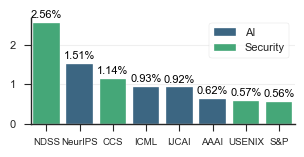

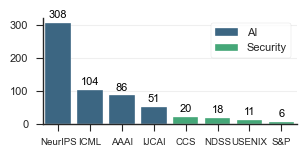

In [4]:
# Statistics: Papers with Invalid Citations and Their Proportion per Conference

# Total unique papers with at least one invalid citation
total_invalid_papers = df.groupby(['Filename', 'Conf'])
print(f"Total unique papers with invalid citations: {total_invalid_papers.size()}")

# Invalid papers per conference
invalid_per_conf = df.groupby(['Conf'])['Filename'].nunique().reset_index(name='Invalid_Papers')
# invalid_per_conf.to_csv('invalid_papers_per_conference.csv', index=False)
# Load total papers data from statistics folder
# Adjust path if necessary
total_df = pd.read_csv('statistics/papers_count_per_year.csv', encoding='gbk')
# Group by Conference and Domain to preserve Domain info
total_per_conf = total_df.groupby(['Conference', 'Domain'])['Count'].sum().reset_index(name='Total_Papers')

# Standardize conference names to handle variations
standard_names = {
    "Neurips": "NeurIPS",
    "NeurIPS": "NeurIPS",
    "SP": "S&P",
    "S&P": "S&P",
    # Add other mappings if needed
}

invalid_per_conf['Conf'] = invalid_per_conf['Conf'].map(standard_names).fillna(invalid_per_conf['Conf'])
total_per_conf['Conference'] = total_per_conf['Conference'].map(standard_names).fillna(total_per_conf['Conference'])

# Merge invalid and total
merged = pd.merge(invalid_per_conf, total_per_conf, left_on='Conf', right_on='Conference', how='left')
merged['Percentage'] = (merged['Invalid_Papers'] / merged['Total_Papers']) * 100

print("\nProportion of papers with invalid citations per conference:")
print(merged.head())
# ==========================================
# Plot 1: Percentage
# ==========================================
plt.figure(figsize=(3, 1.5))
# Order by Percentage descending
order_pct = merged.sort_values('Percentage', ascending=False)['Conf']
ax1 = sns.barplot(
    data=merged,
    x='Conf',
    y='Percentage',
    hue='Domain',
    palette='viridis',
    order=order_pct,
    dodge=False
)

ax1.margins(x=0.01)
plt.ylabel('')
plt.xlabel('', fontsize=12)
plt.xticks(size=7)
plt.legend()

# Annotate bars
for p in ax1.patches:
    height = p.get_height()
    if height <= 0 or pd.isna(height): continue
    ax1.annotate(f'{height:.2f}%', 
                (p.get_x() + p.get_width() / 2, height), 
                xytext=(0, 2), textcoords='offset points',
                ha='center', va='bottom', fontsize=8, color='black')

plt.tight_layout(pad=0.36)
plt.savefig('invalid_papers_proportion.pdf', dpi=300)
plt.show()

# ==========================================
# Plot 2: Number of Papers
# ==========================================
plt.figure(figsize=(3, 1.5))
# Order by Invalid_Papers descending
order_count = merged.sort_values('Invalid_Papers', ascending=False)['Conf']
ax2 = sns.barplot(
    data=merged,
    x='Conf',
    y='Invalid_Papers',
    hue='Domain',
    palette='viridis',
    order=order_count,
    dodge=False 
)

ax2.margins(x=0.01)
plt.ylabel('')
plt.xlabel('', fontsize=12)
plt.xticks(size=7)
plt.legend()

# Annotate bars
for p in ax2.patches:
    height = p.get_height()
    if height <= 0 or pd.isna(height): continue
    ax2.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2, height), 
                xytext=(0, 2), textcoords='offset points',
                ha='center', va='bottom', fontsize=8, color='black')

plt.tight_layout(pad=0.36)
plt.savefig('invalid_papers_count.pdf', dpi=300)
plt.show()

In [5]:
fngp = df.groupby(['Filename', "Conf"])
print(fngp.size())
totalGhost, totalError, ghost_and_error = 0, 0, 0
for name, group in fngp:
    hasGhost = any(group['Is Corrected'] == True)
    hasError = any(group['Is Corrected'] == False)
    if hasGhost:
        totalGhost += 1
    if hasError:
        totalError += 1
    if hasGhost and hasError:
        ghost_and_error += 1
    if not hasGhost and not hasError:
        print(f"Error: Paper {name} has no invalid citations but is in the dataset.")
print(f"Total Papers with Ghost Citations: {totalGhost}")
print(f"Total Papers with Error Citations: {totalError}")
print(f"Papers with both Ghost and Error Citations: {ghost_and_error}")


Filename     Conf   
0000001.pdf  NDSS       1
0000002.pdf  NDSS       1
0000004.pdf  NDSS       3
0000013.pdf  NDSS       1
0000015.pdf  NDSS       1
                       ..
yPC9zmkQgG   NeurIPS    1
yRxXTdElLv   NeurIPS    1
ypVW5jvguX   NeurIPS    2
zho5kN8jTn   NeurIPS    1
zkGfPYAM5D   ICML       1
Length: 604, dtype: int64
Total Papers with Ghost Citations: 486
Total Papers with Error Citations: 133
Papers with both Ghost and Error Citations: 15


In [6]:
# Calculate proportion of papers with invalid citations per year

# 1. Count unique papers with invalid citations per year
invalid_papers_per_year = df.groupby('Year')['Filename'].nunique().reset_index(name='Invalid_Papers')
invalid_papers_per_year['Year'] = invalid_papers_per_year['Year'].astype(int)

# 2. Load total papers per year (sum across all conferences)
total_df = pd.read_csv('statistics/papers_count_per_year.csv', encoding='gbk')
total_papers_per_year = total_df.groupby('Year')['Count'].sum().reset_index(name='Total_Papers')
total_papers_per_year['Year'] = total_papers_per_year['Year'].astype(int)

# 3. Merge and calculate proportion
proportion_df = pd.merge(
    invalid_papers_per_year, 
    total_papers_per_year, 
    on='Year', 
    how='outer'
).fillna(0)

# Calculate percentage
proportion_df['Proportion'] = (proportion_df['Invalid_Papers'] / proportion_df['Total_Papers']) * 100

# Sort by year
proportion_df = proportion_df.sort_values('Year')

print(proportion_df)

   Year  Invalid_Papers  Total_Papers  Proportion
0  2020              52          6118    0.849951
1  2021              52          6862    0.757797
2  2022              70          7325    0.955631
3  2023              81          9233    0.877288
4  2024             120         12236    0.980713
5  2025             235         14607    1.608818


Total unique papers with invalid citations: 596

Proportion of papers with invalid citations per conference:


,Conf,Domain,Invalid_Papers,Total_Papers,Percentage
0,AAAI,AI,86,13821,0.62
1,CCS,Security,20,1756,1.14
2,ICML,AI,104,11192,0.93
3,IJCAI,AI,51,5535,0.92
4,NDSS,Security,18,702,2.56
5,NeurIPS,AI,308,20387,1.51
6,S&P,Security,6,1073,0.56
7,USENIX,Security,11,1915,0.57


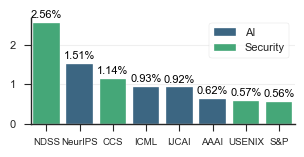

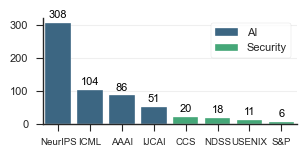

In [7]:
# Statistics: Papers with Error Citations, Ghost Citations, and Their Proportion per Conference

# Total unique papers with at least one invalid citation
total_invalid_papers = df['Filename'].nunique()
print(f"Total unique papers with invalid citations: {total_invalid_papers}")

# Invalid papers per conference
invalid_per_conf = df.groupby('Conf')['Filename'].nunique().reset_index(name='Invalid_Papers')

# Load total papers data from statistics folder
# Adjust path if necessary
total_df = pd.read_csv('statistics/papers_count_per_year.csv', encoding='gbk')
# Group by Conference and Domain to preserve Domain info
total_per_conf = total_df.groupby(['Conference', 'Domain'])['Count'].sum().reset_index(name='Total_Papers')

# Standardize conference names to handle variations
standard_names = {
    "Neurips": "NeurIPS",
    "NeurIPS": "NeurIPS",
    "SP": "S&P",
    "S&P": "S&P",
    # Add other mappings if needed
}

invalid_per_conf['Conf'] = invalid_per_conf['Conf'].map(standard_names).fillna(invalid_per_conf['Conf'])
total_per_conf['Conference'] = total_per_conf['Conference'].map(standard_names).fillna(total_per_conf['Conference'])

# Merge invalid and total
merged = pd.merge(invalid_per_conf, total_per_conf, left_on='Conf', right_on='Conference', how='left')
merged['Percentage'] = (merged['Invalid_Papers'] / merged['Total_Papers']) * 100

print("\nProportion of papers with invalid citations per conference:")
display(merged[['Conf', 'Domain', 'Invalid_Papers', 'Total_Papers', 'Percentage']].round(2))

# ==========================================
# Plot 1: Percentage
# ==========================================
plt.figure(figsize=(3, 1.5))
# Order by Percentage descending
order_pct = merged.sort_values('Percentage', ascending=False)['Conf']
ax1 = sns.barplot(
    data=merged,
    x='Conf',
    y='Percentage',
    hue='Domain',
    palette='viridis',
    order=order_pct,
    dodge=False
)

ax1.margins(x=0.01)
plt.ylabel('')
plt.xlabel('', fontsize=12)
plt.xticks(size=7)
plt.legend()

# Annotate bars
for p in ax1.patches:
    height = p.get_height()
    if height <= 0 or pd.isna(height): continue
    ax1.annotate(f'{height:.2f}%', 
                (p.get_x() + p.get_width() / 2, height), 
                xytext=(0, 2), textcoords='offset points',
                ha='center', va='bottom', fontsize=8, color='black')

plt.tight_layout(pad=0.36)
plt.savefig('invalid_papers_proportion.pdf', dpi=300)
plt.show()

# ==========================================
# Plot 2: Number of Papers
# ==========================================
plt.figure(figsize=(3, 1.5))
# Order by Invalid_Papers descending
order_count = merged.sort_values('Invalid_Papers', ascending=False)['Conf']
ax2 = sns.barplot(
    data=merged,
    x='Conf',
    y='Invalid_Papers',
    hue='Domain',
    palette='viridis',
    order=order_count,
    dodge=False 
)

ax2.margins(x=0.01)
plt.ylabel('')
plt.xlabel('', fontsize=12)
plt.xticks(size=7)
plt.legend()

# Annotate bars
for p in ax2.patches:
    height = p.get_height()
    if height <= 0 or pd.isna(height): continue
    ax2.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2, height), 
                xytext=(0, 2), textcoords='offset points',
                ha='center', va='bottom', fontsize=8, color='black')

plt.tight_layout(pad=0.36)
plt.savefig('invalid_papers_count.pdf', dpi=300)
plt.show()

## 5.2 Temporal Trends (2020-2025)

Investigating if the prevalence of invalid citations has changed with the rise of GenAI (post-2022).

   Year  Invalid_Papers  Total_Papers  Proportion
0  2020              52          6118    0.849951
1  2021              52          6862    0.757797
2  2022              70          7325    0.955631
3  2023              81          9233    0.877288
4  2024             120         12236    0.980713
5  2025             235         14607    1.608818


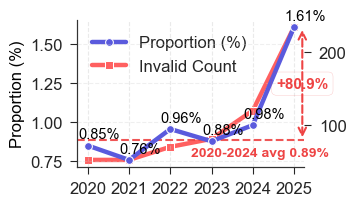

In [ ]:
# Calculate proportion of papers with invalid citations per year

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'axes.facecolor': '#FFFFFF',
    'figure.facecolor': 'white',
    'mathtext.fontset': 'stixsans',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'grid.linestyle': '--',
    'grid.alpha': 0.4,
})

# 1. Count unique papers with invalid citations per year
invalid_papers_per_year = df.groupby('Year')['Filename'].nunique().reset_index(name='Invalid_Papers')
invalid_papers_per_year['Year'] = invalid_papers_per_year['Year'].astype(int)

# 2. Load total papers per year (sum across all conferences)
total_df = pd.read_csv('statistics/papers_count_per_year.csv', encoding='gbk')
total_papers_per_year = total_df.groupby('Year')['Count'].sum().reset_index(name='Total_Papers')
total_papers_per_year['Year'] = total_papers_per_year['Year'].astype(int)

# 3. Merge and calculate proportion
proportion_df = pd.merge(
    invalid_papers_per_year, 
    total_papers_per_year, 
    on='Year', 
    how='outer'
).fillna(0)

# Calculate percentage
proportion_df['Proportion'] = (proportion_df['Invalid_Papers'] / proportion_df['Total_Papers']) * 100

# Sort by year
proportion_df = proportion_df.sort_values('Year')

print(proportion_df)
plt.figure(figsize=(3.5, 2))

colors = {'AI': "#5A5ADD", 'Security': "#FF6060"}

ax1 = sns.lineplot(
    data=proportion_df, x='Year', y='Proportion',
    marker='o', linewidth=3.2, color=colors['AI'], ax=plt.gca(), zorder=3, 
    label='Proportion (%)', legend=False
)

twincolor = colors['Security']
ax2 = ax1.twinx()
sns.lineplot(
    data=proportion_df, x='Year',  y='Invalid_Papers',
    marker='s', linewidth=3.2, color=twincolor, ax=ax2, zorder=2, 
    label='Invalid Count', legend=False
)
ax1.set_ylabel('')
ax2.set_ylabel('')
ax2.set_xlabel('')
ax1.set_xlabel('')
ax1.set_axisbelow(True)
ax1.grid(True, axis='y', alpha=0.3)
ax2.grid(False)
# ax2.set_ylabel('Invalid Count', color=twincolor)

ax1.set_zorder(2)
ax2.set_zorder(1)
ax1.patch.set_visible(False)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
l2 = [l.replace('Invalid Papers Count', 'Invalid Papers') for l in l2]
ax2.legend(h1+h2, l1+l2, loc='upper left',
           fontsize=12,
           frameon=False, facecolor='none', edgecolor='none')

for x, y, z in zip(proportion_df['Year'], proportion_df['Proportion'], proportion_df['Invalid_Papers']):
    ax1.annotate(f'{y:.2f}%', (x, y), textcoords="offset points", xytext=(8, 5), ha='center', fontsize=10.5, color='black', )

avg_2020_2024 = proportion_df[(proportion_df['Year'] >= 2020) & (proportion_df['Year'] <= 2024)]['Proportion'].mean()
prop_2025 = proportion_df[proportion_df['Year'] == 2025]['Proportion'].values[0]
mid_y = (avg_2020_2024 + prop_2025) / 2
increase_pct = (prop_2025 - avg_2020_2024) / avg_2020_2024 * 100

ax1.axhline(avg_2020_2024, color='#EE4444', lw=1.5, linestyle='--', zorder=1, alpha=0.9)
ax1.text(2022.5, avg_2020_2024 - 0.12, '2020-2024 avg 0.89%',
         fontsize=10, color='#EE4444', va='bottom', fontweight='bold')

ax1.annotate('', xy=(2025.2, prop_2025), xytext=(2025.2, avg_2020_2024),
            arrowprops=dict(arrowstyle='<->', color='#EE4444', lw=1.5, linestyle='--'), zorder=1)
ax1.text(2025.2, mid_y, f'+{80.9}%', ha='center', va='center',
         fontsize=11, color='#EE4444', weight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='none', edgecolor='#EE4444', alpha=0.4))
    
plt.xticks(sorted(df['Year'].dropna().unique().astype(int)))
ax1.tick_params(axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)
ax1.set_ylabel('Proportion (%)', color='black', fontsize=12)

plt.tight_layout(pad=0.36)
plt.savefig('papers_with_invalid_citations_timetrend.pdf', dpi=300)

    Year    Domain  Invalid_Papers  Total_Papers  Proportion
0   2020        AI              44          5624    0.782361
1   2020  Security               8           494    1.619433
2   2021        AI              46          6196    0.742414
3   2021  Security               6           666    0.900901
4   2022        AI              62          6553    0.946132
5   2022  Security               8           772    1.036269
6   2023        AI              70          8235    0.850030
7   2023  Security              11           998    1.102204
8   2024        AI             108         11017    0.980303
9   2024  Security              12          1219    0.984413
10  2025        AI             225         13310    1.690458
11  2025  Security              10          1297    0.771010


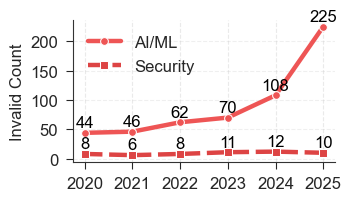

In [9]:
# Calculate proportion of papers with invalid citations per year BY DOMAIN (AI vs Security)

# 1. Count unique papers with invalid citations per year and domain
invalid_papers_per_year_domain = df.groupby(['Year', 'Domain'])['Filename'].nunique().reset_index(name='Invalid_Papers')
invalid_papers_per_year_domain['Year'] = invalid_papers_per_year_domain['Year'].astype(int)

# 2. Load total papers per year grouped by domain
total_df = pd.read_csv('statistics/papers_count_per_year.csv', encoding='gbk')
total_papers_per_year_domain = total_df.groupby(['Year', 'Domain'])['Count'].sum().reset_index(name='Total_Papers')
total_papers_per_year_domain['Year'] = total_papers_per_year_domain['Year'].astype(int)

# 3. Merge and calculate proportion
proportion_domain_df = pd.merge(
    invalid_papers_per_year_domain, 
    total_papers_per_year_domain, 
    on=['Year', 'Domain'], 
    how='outer'
).fillna(0)

# Calculate percentage
proportion_domain_df['Proportion'] = (proportion_domain_df['Invalid_Papers'] / proportion_domain_df['Total_Papers']) * 100

# Sort by year and domain
proportion_domain_df = proportion_domain_df.sort_values(['Year', 'Domain'])

# Filter only AI and Security domains
proportion_domain_df = proportion_domain_df[proportion_domain_df['Domain'].isin(['AI', 'Security'])]

print(proportion_domain_df)

# Use different colors for AI and Security
colors = {'AI': "#EE5555", 'Security': "#DD4444"}

# Plot: Count chart only
plt.figure(figsize=(3.5, 2))

ax = sns.lineplot(
    data=proportion_domain_df, 
    x='Year', 
    y='Invalid_Papers',
    hue='Domain',
    style='Domain',
    markers=['o', 's'],
    # lineshape
    
    linewidth=3.2,
    palette=colors,
)

ax.set_xlabel('')
ax.set_axisbelow(True)
ax.grid(True, axis='y', alpha=0.3)

# Add annotations for count chart
for domain in ['AI', 'Security']:
    domain_data = proportion_domain_df[proportion_domain_df['Domain'] == domain]
    for x, y, z in zip(domain_data['Year'], domain_data['Invalid_Papers'], domain_data['Proportion']):
        offset_y = 5 if domain == 'AI/ML' else 4
        ax.annotate(f'{int(y)}', (x, y), textcoords="offset points", xytext=(0, offset_y), ha='center', fontsize=12, color='black')

handles, labels = ax.get_legend_handles_labels()
labels = ['AI/ML', 'Security']
# set custom legend
ax.legend(handles, labels, title='', frameon=False, loc='upper left', fontsize=12)

ax.set_xticks(sorted(df['Year'].dropna().unique().astype(int)))
ax.set_title('', fontsize=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax.set_ylabel('Invalid Count', fontsize=12)


plt.tight_layout(pad=0.5)
plt.savefig('papers_with_invalid_citations_timetrend_by_venue.pdf', dpi=300)
plt.show()

## Additional Analysis: Recycled Hallucinations

Are distinct papers citing the *same* invalid paper? This might indicate a common source (e.g., a specific LLM hallucination repeated).

In [10]:
# Normalize titles to title case for consistent grouping
df['Cite Title Normalized'] = df['Cite Title'].str.title()

# Group by Cite Title (normalized) and count occurrences
recycled = df.groupby('Cite Title Normalized').agg(
    Count=('Cite Title Normalized', 'count'),
    Cited_By_Papers=('Filename', lambda x: x.nunique()),
    Venues=('Conf', lambda x: list(x.unique()))
).sort_values('Count', ascending=False)

print("Top Repeated Invalid Citations:")
display(recycled.head(10))

# Check if there are any cross-domain hallucinations (cited in both AI and Security)
def is_cross_domain(venues):
    domain_set = set([get_domain(v) for v in venues])
    return 'AI' in domain_set and 'Security' in domain_set

recycled['Cross_Domain'] = recycled['Venues'].apply(is_cross_domain)
cross_domain_hallucinations = recycled[recycled['Cross_Domain']]

if not cross_domain_hallucinations.empty:
    print("\nFound Cross-Domain Hallucinations:")
    display(cross_domain_hallucinations)
else:
    print("\nNo invalid citations found that appear in both AI and Security venues.")

Top Repeated Invalid Citations:


,Count,Cited_By_Papers,Venues
Cite Title Normalized,,,
Augmix: A Simple Method To Improve Robustness And Uncertainty Under Data Shift,16,16,"[AAAI, IJCAI, NeurIPS]"
Reduction Of A Game With Complete Memory To A Matrix Game,7,7,"[AAAI, NeurIPS]"
Towards Private Synthetic Text Generation,5,5,[ICML]
Turing: Composable Inference For Probabilistic Programming,3,3,[ICML]
On The Systematic Fitting Of Frequency Curves,3,3,[NeurIPS]
A Multi-Illumination Dataset Of Indoor Object Appearance,3,3,"[ICML, NeurIPS]"
Keeping Neural Networks Simple By Minimising The Description Length Of Weights,3,3,"[ICML, NeurIPS]"
Algorithm Cnneim-A And Its Mean Complexity,3,3,"[ICML, NeurIPS]"
Deepip: Deep Neural Network Intellectual Property Protection With Passports,3,3,"[USENIX, CCS, NeurIPS]"



Found Cross-Domain Hallucinations:


,Count,Cited_By_Papers,Venues,Cross_Domain
Cite Title Normalized,,,,
Deepip: Deep Neural Network Intellectual Property Protection With Passports,3,3,"[USENIX, CCS, NeurIPS]",True


## 5.4 Concentration of Invalid Citations per Paper

Analyze which papers contain multiple invalid citations. This helps identify "worst offender" papers that may be heavily reliant on hallucinated content or low-quality generation tools.

Top 10 Papers with Most Invalid Citations:


,Filename,Conf,Year,Domain,Invalid_Count
93,1111549,AAAI,2024,AI,9
78,1110915,AAAI,2025,AI,6
454,VN5bMTfSZS,NeurIPS,2025,AI,5
470,Zb3QO7HLIj,NeurIPS,2025,AI,5
568,kWGJa9ZO3M,NeurIPS,2025,AI,5
412,GPTI9GNAYH,NeurIPS,2025,AI,5
420,IiEtQPGVyV,NeurIPS,2025,AI,4
566,jwjvkWsePB,ICML,2025,AI,4
304,6ZkcC9NmGU,NeurIPS,2025,AI,4
18,0000187.pdf,NDSS,2025,Security,4


,Invalid_Count,Paper_Count
0,1,542
1,2,37
2,3,16
3,4,10
4,5,4
5,9,1
6,6,1
7,7,0
8,8,0


C:\Users\20532\AppData\Local\Temp\ipykernel_93792\509772797.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


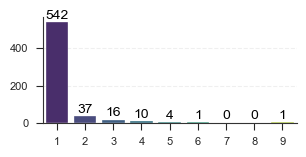

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is already defined and loaded
# Group by Filename and count invalid citations
paper_counts = df.groupby(['Filename', 'Conf', 'Year', 'Domain']).size().reset_index(name='Invalid_Count')
paper_counts = paper_counts.sort_values('Invalid_Count', ascending=False)
invalid_counts_paper_count = paper_counts['Invalid_Count'].value_counts().reset_index()
invalid_counts_paper_count.columns = ['Invalid_Count', 'Paper_Count']

min_count = 1
max_count = paper_counts['Invalid_Count'].max()
for i in range(min_count, max_count + 1):
    if i not in invalid_counts_paper_count['Invalid_Count'].values:
        invalid_counts_paper_count = pd.concat([invalid_counts_paper_count, pd.DataFrame({'Invalid_Count': [i], 'Paper_Count': [0]})], ignore_index=True)

print("Top 10 Papers with Most Invalid Citations:")
display(paper_counts.head(10))
display(invalid_counts_paper_count.head(10))

# Plot distribution of Invalid Citations per Paper
plt.figure(figsize=(3, 1.5))

ax = sns.barplot(
    data=invalid_counts_paper_count, 
    x='Invalid_Count', 
    y='Paper_Count', 
    palette='viridis', 
    order=sorted(invalid_counts_paper_count['Invalid_Count'].unique())
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2, p.get_height()+ 1), 
                ha='center', va='bottom', fontsize=10, color='black')

# plt.title('Distribution of Invalid Citations Per Paper', fontsize=16)
plt.xlabel('')
plt.ylabel('')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout(pad=0.36)
plt.savefig('invalid_citations_per_paper_distribution.pdf', dpi=300)

## Export Results to Markdown

Save all analysis results to a markdown report file.

In [12]:
# Generate Markdown Report
from datetime import datetime

def generate_markdown_report():
    report_lines = []
    
    # Header
    report_lines.append("# Invalid Citation Analysis Report")
    report_lines.append(f"\n**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    report_lines.append("\n---\n")
    
    # Section 1: Overview
    report_lines.append("## 1. Overview")
    report_lines.append(f"\n- **Total invalid citation records:** {len(df)}")
    report_lines.append(f"- **Total unique papers with invalid citations:** {df['Filename'].nunique()}")
    report_lines.append(f"- **Conferences analyzed:** {', '.join(df['Conf'].unique())}")
    report_lines.append(f"- **Years covered:** {int(df['Year'].min())} - {int(df['Year'].max())}")
    report_lines.append("\n### Domain Distribution")
    domain_dist = df['Domain'].value_counts()
    for domain, count in domain_dist.items():
        report_lines.append(f"- {domain}: {count} invalid citations")
    
    # Section 2: Conference Statistics
    report_lines.append("\n---\n")
    report_lines.append("## 2. Invalid Citations by Conference")
    report_lines.append("\n| Conference | Domain | Invalid Papers | Total Papers | Percentage |")
    report_lines.append("|------------|--------|----------------|--------------|------------|")
    for _, row in merged.iterrows():
        report_lines.append(f"| {row['Conf']} | {row['Domain']} | {row['Invalid_Papers']} | {row['Total_Papers']} | {row['Percentage']:.2f}% |")
    
    # Section 3: Temporal Trends
    report_lines.append("\n---\n")
    report_lines.append("## 3. Temporal Trends (2020-2025)")
    report_lines.append("\n| Year | Invalid Papers | Total Papers | Proportion (%) |")
    report_lines.append("|------|----------------|--------------|----------------|")
    for _, row in proportion_df.iterrows():
        report_lines.append(f"| {int(row['Year'])} | {int(row['Invalid_Papers'])} | {int(row['Total_Papers'])} | {row['Proportion']:.2f}% |")
    
    # Key findings for temporal trends
    pre_genai = proportion_df[proportion_df['Year'] < 2023]['Proportion'].mean()
    post_genai = proportion_df[proportion_df['Year'] >= 2023]['Proportion'].mean()
    report_lines.append(f"\n### Key Findings")
    report_lines.append(f"- **Pre-GenAI (2020-2022) average proportion:** {pre_genai:.2f}%")
    report_lines.append(f"- **Post-GenAI (2023-2025) average proportion:** {post_genai:.2f}%")
    if post_genai > pre_genai:
        report_lines.append(f"- **Increase:** {((post_genai - pre_genai) / pre_genai * 100):.1f}% rise in invalid citation rate")
    
    # Section 4: Recycled Hallucinations
    report_lines.append("\n---\n")
    report_lines.append("## 4. Recycled Hallucinations Analysis")
    report_lines.append("\nInvalid citations that appear in multiple papers:")
    report_lines.append("\n| Cite Title | Count | Papers Citing | Venues |")
    report_lines.append("|------------|-------|---------------|--------|")
    for title, row in recycled.head(10).iterrows():
        title_truncated = title[:60] + "..." if len(title) > 60 else title
        venues_str = ", ".join(row['Venues'])
        report_lines.append(f"| {title_truncated} | {row['Count']} | {row['Cited_By_Papers']} | {venues_str} |")
    
    # Cross-domain hallucinations
    if not cross_domain_hallucinations.empty:
        report_lines.append("\n### Cross-Domain Hallucinations")
        report_lines.append("\nInvalid citations appearing in both AI and Security venues:")
        for title, row in cross_domain_hallucinations.iterrows():
            report_lines.append(f"- **{title}** (Count: {row['Count']}, Venues: {', '.join(row['Venues'])})")
    else:
        report_lines.append("\n*No cross-domain hallucinations found.*")
    
    # Section 5: Invalid Citations per Paper Distribution
    report_lines.append("\n---\n")
    report_lines.append("## 5. Invalid Citations per Paper Distribution")
    report_lines.append("\n| Invalid Count | Number of Papers |")
    report_lines.append("|---------------|------------------|")
    dist_sorted = invalid_counts_paper_count.sort_values('Invalid_Count')
    for _, row in dist_sorted.iterrows():
        report_lines.append(f"| {int(row['Invalid_Count'])} | {int(row['Paper_Count'])} |")
    
    # Statistics
    single_invalid = invalid_counts_paper_count[invalid_counts_paper_count['Invalid_Count'] == 1]['Paper_Count'].sum()
    multiple_invalid = invalid_counts_paper_count[invalid_counts_paper_count['Invalid_Count'] > 1]['Paper_Count'].sum()
    total_papers_with_invalid = single_invalid + multiple_invalid
    report_lines.append(f"\n### Statistics")
    report_lines.append(f"- Papers with exactly 1 invalid citation: {single_invalid} ({single_invalid/total_papers_with_invalid*100:.1f}%)")
    report_lines.append(f"- Papers with 2+ invalid citations: {multiple_invalid} ({multiple_invalid/total_papers_with_invalid*100:.1f}%)")
    
    # Top offenders
    report_lines.append("\n### Top 10 Papers with Most Invalid Citations")
    report_lines.append("\n| Filename | Conference | Year | Domain | Invalid Count |")
    report_lines.append("|----------|------------|------|--------|---------------|")
    for _, row in paper_counts.head(10).iterrows():
        report_lines.append(f"| {row['Filename']} | {row['Conf']} | {int(row['Year'])} | {row['Domain']} | {row['Invalid_Count']} |")
    
    # Section 6: Summary
    report_lines.append("\n---\n")
    report_lines.append("## 6. Summary")
    report_lines.append("\n### Key Observations")
    
    # Find conference with highest rate
    max_rate_conf = merged.loc[merged['Percentage'].idxmax()]
    report_lines.append(f"1. **Highest invalid citation rate:** {max_rate_conf['Conf']} with {max_rate_conf['Percentage']:.2f}%")
    
    # Find conference with most invalid papers
    max_count_conf = merged.loc[merged['Invalid_Papers'].idxmax()]
    report_lines.append(f"2. **Most invalid papers (by count):** {max_count_conf['Conf']} with {int(max_count_conf['Invalid_Papers'])} papers")
    
    # Year with most growth
    latest_year = proportion_df['Year'].max()
    latest_proportion = proportion_df[proportion_df['Year'] == latest_year]['Proportion'].values[0]
    report_lines.append(f"3. **Latest year ({int(latest_year)}) invalid citation rate:** {latest_proportion:.2f}%")
    
    # Most repeated hallucination
    top_recycled = recycled.head(1)
    if not top_recycled.empty:
        top_title = top_recycled.index[0]
        top_count = top_recycled['Count'].values[0]
        report_lines.append(f"4. **Most repeated invalid citation:** \"{top_title[:50]}...\" cited in {top_count} papers")
    
    return "\n".join(report_lines)

# Generate and save report
report_content = generate_markdown_report()
report_path = "analysis_report.md"
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_content)

print(f"Report saved to: {report_path}")
print("\n" + "="*50)
print("PREVIEW:")
print("="*50)
print(report_content[:2000] + "\n...[truncated]...")

Report saved to: analysis_report.md

PREVIEW:
# Invalid Citation Analysis Report

**Generated:** 2026-02-06 12:20:31

---

## 1. Overview

- **Total invalid citation records:** 739
- **Total unique papers with invalid citations:** 596
- **Conferences analyzed:** USENIX, NDSS, CCS, S&P, AAAI, ICML, IJCAI, NeurIPS
- **Years covered:** 2020 - 2025

### Domain Distribution
- AI: 675 invalid citations
- Security: 64 invalid citations

---

## 2. Invalid Citations by Conference

| Conference | Domain | Invalid Papers | Total Papers | Percentage |
|------------|--------|----------------|--------------|------------|
| AAAI | AI | 86 | 13821 | 0.62% |
| CCS | Security | 20 | 1756 | 1.14% |
| ICML | AI | 104 | 11192 | 0.93% |
| IJCAI | AI | 51 | 5535 | 0.92% |
| NDSS | Security | 18 | 702 | 2.56% |
| NeurIPS | AI | 308 | 20387 | 1.51% |
| S&P | Security | 6 | 1073 | 0.56% |
| USENIX | Security | 11 | 1915 | 0.57% |

---

## 3. Temporal Trends (2020-2025)

| Year | Invalid Papers | Total Papers |